# National Institutes of Health Chest X-Ray Dataset

Chest X-rays are common and cost-effective but harder to interpret than CT scans. A major challenge for computer-aided diagnosis (CAD) is the lack of large, annotated datasets. Previously, **Openi** was the largest public source with **4,143 images**.  

The **NIH Chest X-ray Dataset** provides **112,120 images** from **30,805 patients**, labeled using **NLP on radiology reports**. Labels are estimated to be **>90% accurate**, making the dataset suitable for **weakly-supervised learning**.  

Details are available in the open-access paper *ChestX-ray8* (Wang et al.).

Dataset Source: https://www.kaggle.com/datasets/nih-chest-xrays/data/home

#### Image Format
 - 112,120 total images with size 1024 x 1024

#### Class Description
There are 15 classes (14 diseases, and one for "No findings"). Images can be classified as "No findings" or one or more disease classes:

 - Atelectasis
 - Consolidation
 - Infiltration
 - Pneumothorax
 - Edema
 - Emphysema
 - Fibrosis
 - Effusion
 - Pneumonia
 - Pleural_thickening
 - Cardiomegaly
 - Nodule Mass
 - Hernia

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import os
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
sns.set_style('whitegrid')
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv("/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv")
data.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [3]:
print('shape of data : ',data.shape)

shape of data :  (112120, 12)


In [4]:
data.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
count,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,0.0
mean,8.573751,14346.381743,46.901463,2646.078844,2486.438842,0.155649,0.155649,NaN
std,15.406320,8403.876972,16.839923,341.246429,401.268227,0.016174,0.016174,NaN
min,0.000000,1.000000,1.000000,1143.000000,966.000000,0.115000,0.115000,NaN
25%,0.000000,7310.750000,35.000000,2500.000000,2048.000000,0.143000,0.143000,NaN
50%,3.000000,13993.000000,49.000000,2518.000000,2544.000000,0.143000,0.143000,NaN
75%,10.000000,20673.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000,NaN
max,183.000000,30805.000000,414.000000,3827.000000,4715.000000,0.198800,0.198800,NaN


### Removing Patients with Age > 100

In [5]:
data = data[['Image Index','Finding Labels','Follow-up #','Patient ID','Patient Age','Patient Gender']]

total = len(data)
print('No. of rows before removing rows having age >100 : ',len(data))
data = data[data['Patient Age']<100]
print('No. of rows after removing rows having age >100 : ',len(data))
print('No. of datapoints having age > 100 : ',total-len(data))

No. of rows before removing rows having age >100 :  112120
No. of rows after removing rows having age >100 :  112104
No. of datapoints having age > 100 :  16


# Exploratory Data Analysis

## Distribution of Chest Pathology Labels
This section illustrates how different chest pathologies are represented in the dataset, highlighting the imbalance across conditions. It provides a quick overview of label frequencies, helping to identify underrepresented classes that may require special handling during model training.

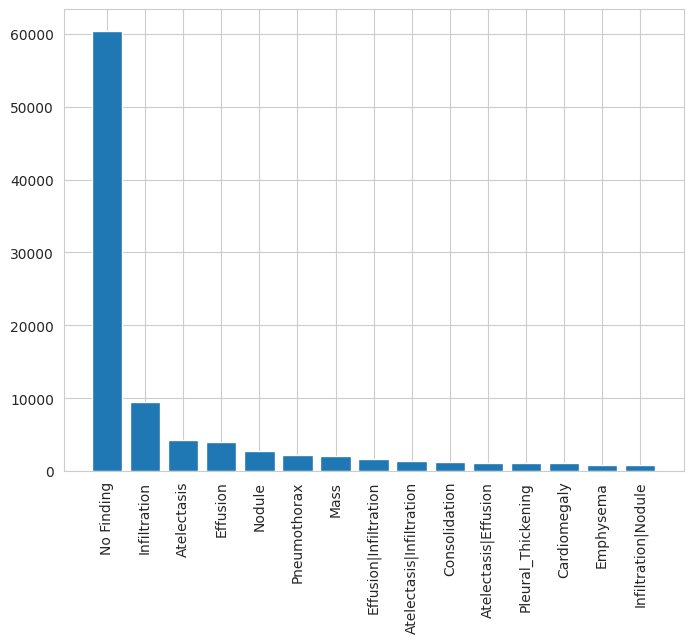

In [6]:
data['Labels_Count'] = data['Finding Labels'].apply(
    lambda text: len(text.split('|')) if (text != 'No Finding') else 0
)

label_counts = data['Finding Labels'].value_counts()[:15]

fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts)
ax1.set_xticks(np.arange(len(label_counts)) + 0.5)
ax1.set_xticklabels(label_counts.index, rotation=90)

plt.show()

## Age distribution
This section shows how patient ages are spread across the dataset, highlighting demographic patterns and potential biases. It helps identify whether certain age groups are over‑ or under‑represented, which is important for ensuring balanced and reliable model training.

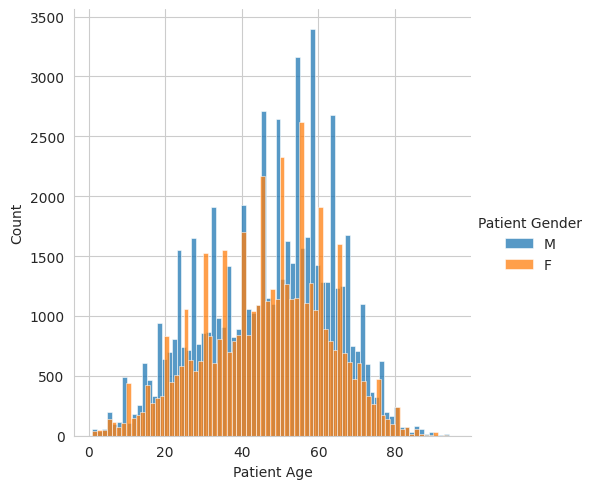

In [7]:
sns.FacetGrid(data, hue='Patient Gender', height=5).map(sns.histplot, 'Patient Age').add_legend() 
plt.show()

## Disease distribution by age and sex
This section examines how chest pathologies are distributed across different age groups and between male and female patients. It highlights demographic trends and potential biases in disease prevalence, providing insights into how age and sex may influence model performance and generalizability.

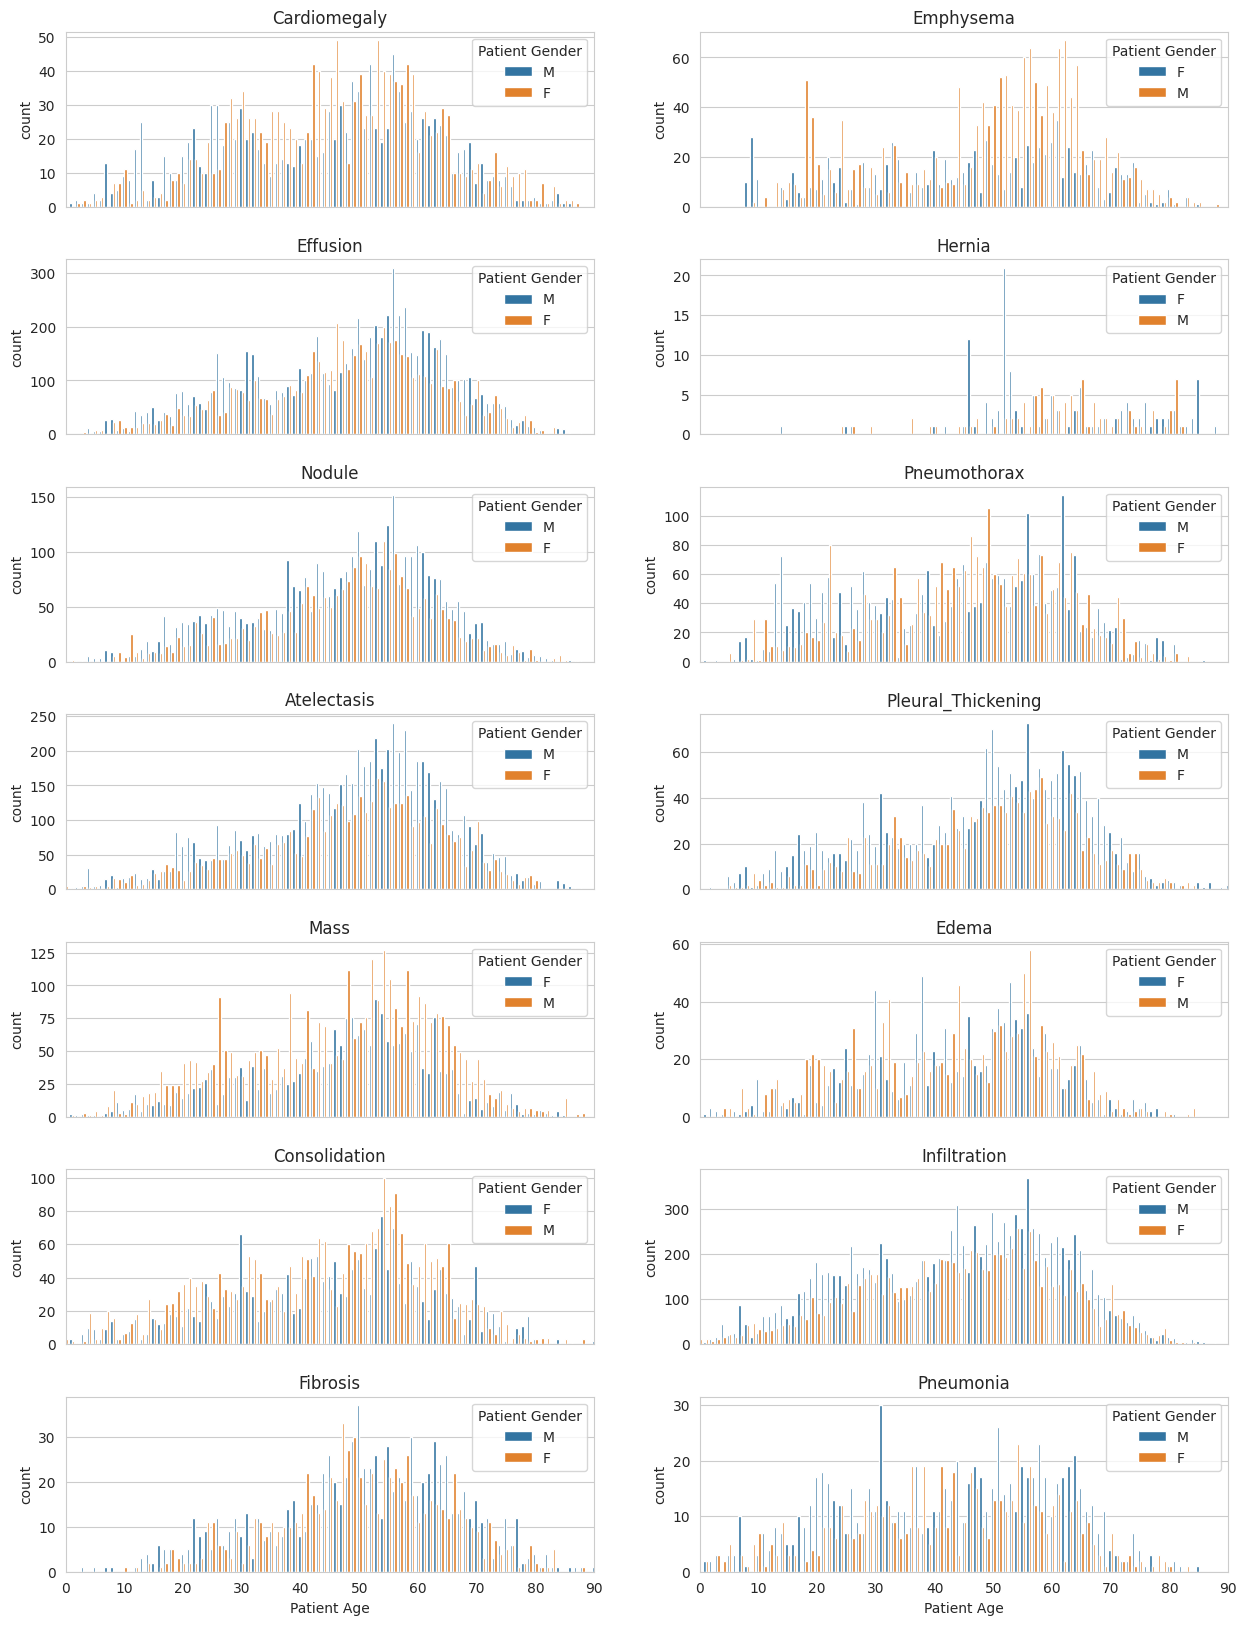

In [8]:
f, axarr = plt.subplots(7, 2, sharex=True,figsize=(15, 20))
pathology_list = ['Cardiomegaly','Emphysema','Effusion','Hernia','Nodule','Pneumothorax','Atelectasis','Pleural_Thickening','Mass','Edema','Consolidation','Infiltration','Fibrosis','Pneumonia']
df = data[data['Finding Labels'] != 'No Finding']
i=0
j=0
x=np.arange(0,100,10)
for pathology in pathology_list :
    index = []
    for k in range(len(df)):
        if pathology in df.iloc[k]['Finding Labels']:
            index.append(k)
    g=sns.countplot(x='Patient Age', hue="Patient Gender",data=df.iloc[index], ax=axarr[i, j])
    axarr[i, j].set_title(pathology)   
    g.set_xlim(0,90)
    g.set_xticks(x)
    g.set_xticklabels(x)
    j=(j+1)%2
    if j==0:
        i=(i+1)%7
f.subplots_adjust(hspace=0.3)

## No. of each disease by patient gender
This section compares the frequency of chest pathologies between male and female patients. It highlights gender-based differences in disease occurrence, helping to identify potential demographic biases and guiding model development toward fairer, more representative outcomes.

In [9]:
for pathology in pathology_list :
    data[pathology] = data['Finding Labels'].apply(lambda x: 1 if pathology in x else 0)

data.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,Labels_Count,Cardiomegaly,Emphysema,Effusion,...,Nodule,Pneumothorax,Atelectasis,Pleural_Thickening,Mass,Edema,Consolidation,Infiltration,Fibrosis,Pneumonia
0,00000001_000.png,Cardiomegaly,0,1,58,M,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,2,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,2,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,No Finding,0,2,81,M,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,00000003_000.png,Hernia,0,3,81,F,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


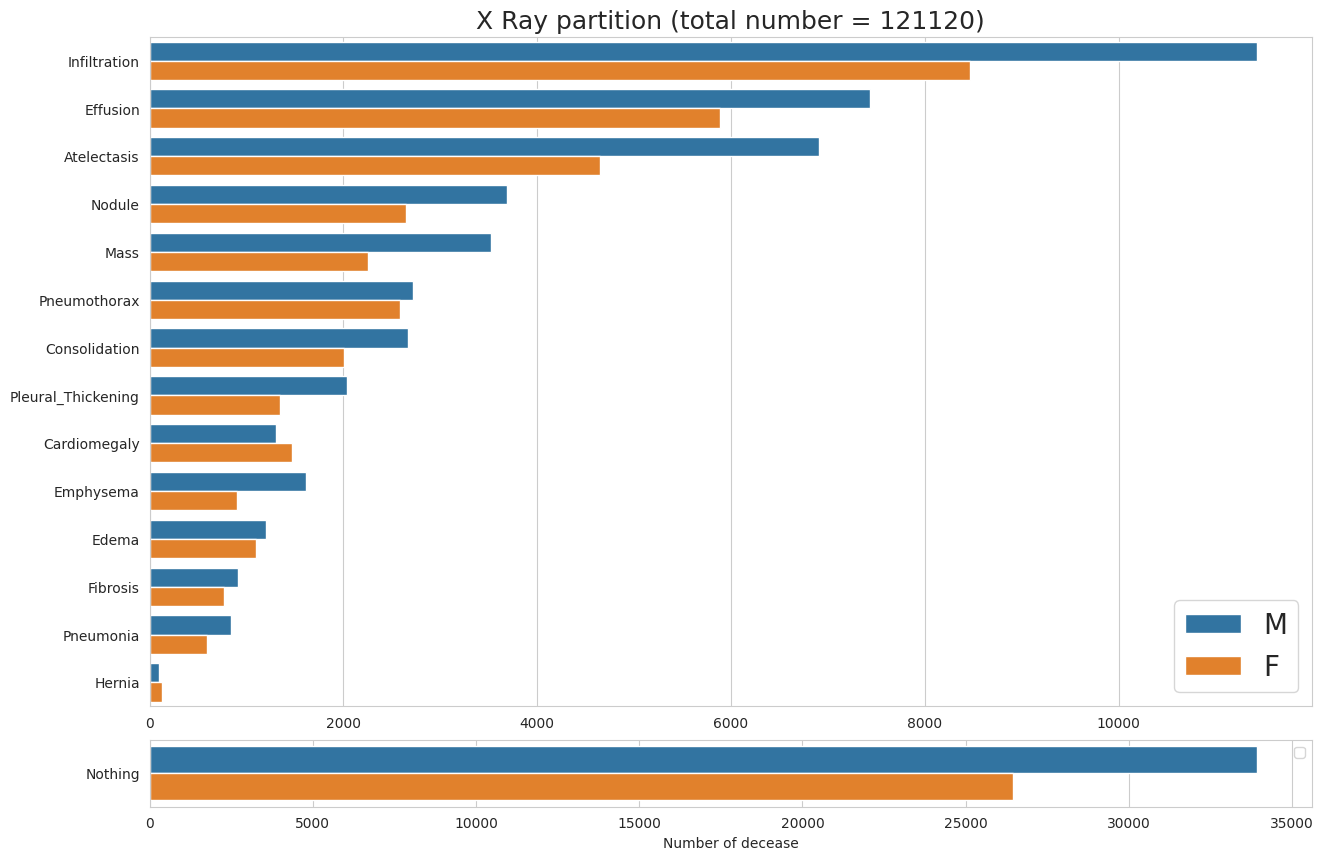

In [10]:
plt.figure(figsize=(15,10))
gs = gridspec.GridSpec(8,1)
ax1 = plt.subplot(gs[:7, :])
ax2 = plt.subplot(gs[7, :])
data1 = pd.melt(data,
             id_vars=['Patient Gender'],
             value_vars = list(pathology_list),
             var_name = 'Category',
             value_name = 'Count')
data1 = data1.loc[data1.Count>0]
g=sns.countplot(y='Category',hue='Patient Gender',data=data1, ax=ax1, order = data1['Category'].value_counts().index)
ax1.set( ylabel="",xlabel="")
ax1.legend(fontsize=20)
ax1.set_title('X Ray partition (total number = 121120)',fontsize=18);

data['Nothing']=data['Finding Labels'].apply(lambda x: 1 if 'No Finding' in x else 0)

data2 = pd.melt(data,
             id_vars=['Patient Gender'],
             value_vars = list(['Nothing']),
             var_name = 'Category',
             value_name = 'Count')
data2 = data2.loc[data2.Count>0]
g=sns.countplot(y='Category',hue='Patient Gender',data=data2,ax=ax2)
ax2.set( ylabel="",xlabel="Number of decease")
ax2.legend('')
plt.subplots_adjust(hspace=.5)

## Ratio between one and multiple disease
This section compares patients with a single diagnosed chest pathology to those with multiple co‑occurring conditions. It highlights the proportion of cases that involve comorbidities, which is important for understanding dataset complexity and guiding model design to handle overlapping disease patterns.

In [11]:
df=data.groupby('Finding Labels').count().sort_values('Patient ID',ascending=False)
df1=df[['|' in index for index in df.index]].copy()
df2=df[['|' not in index for index in df.index]]
df2=df2[['No Finding' not in index for index in df2.index]]
df2['Finding Labels']=df2.index.values
df1['Finding Labels']=df1.index.values

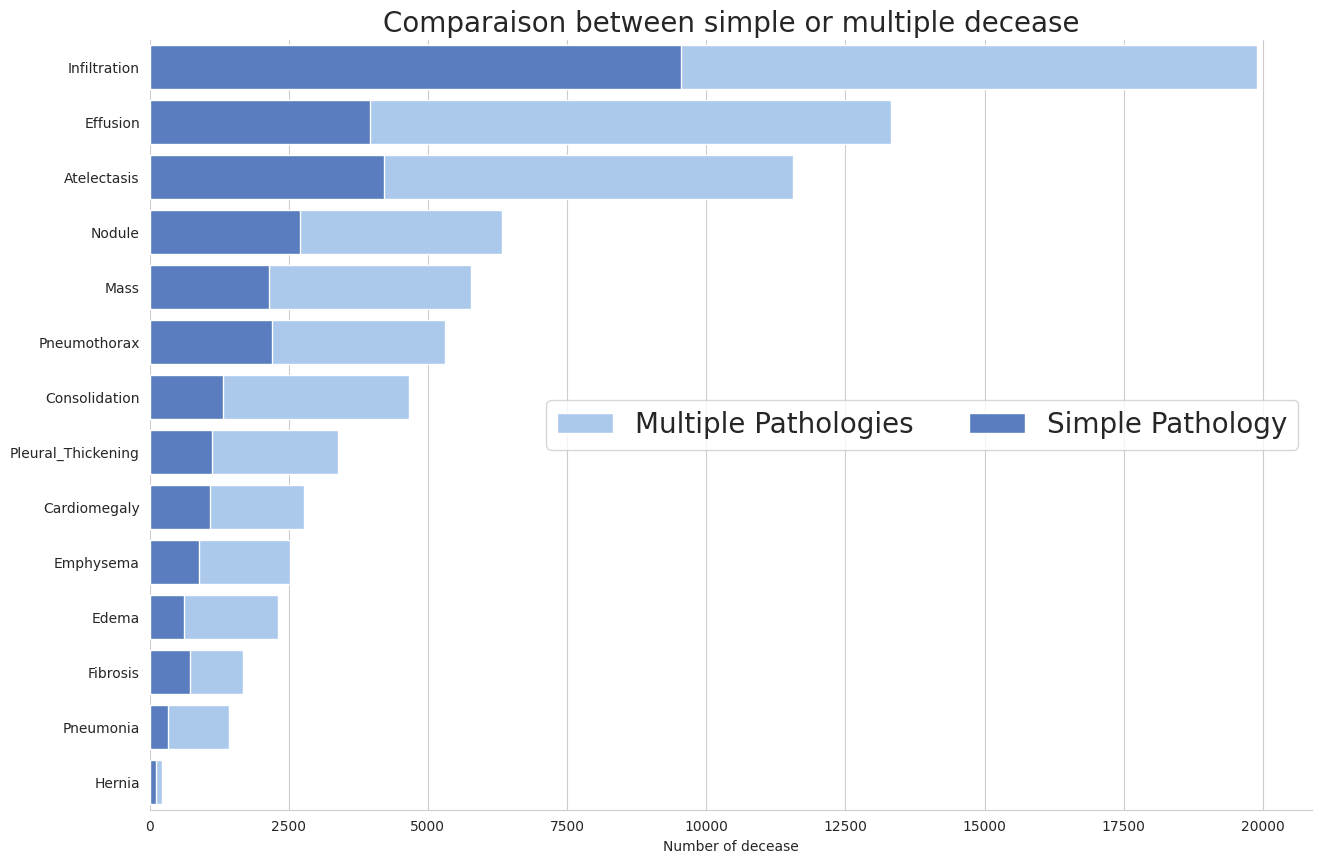

In [12]:
f, ax = plt.subplots(sharex=True,figsize=(15, 10))
sns.set_color_codes("pastel")
g=sns.countplot(y='Category',data=data1, ax=ax, order = data1['Category'].value_counts().index,color='b',label="Multiple Pathologies")
sns.set_color_codes("muted")
g=sns.barplot(x='Patient ID',y='Finding Labels',data=df2, ax=ax, color="b",label="Simple Pathology")
ax.legend(ncol=2, loc="center right", frameon=True,fontsize=20)
ax.set( ylabel="",xlabel="Number of decease")
ax.set_title("Comparaison between simple or multiple decease",fontsize=20)      
sns.despine(left=True)

## Most important pathologies groups for each desease
This section identifies the most frequent combinations of chest pathologies observed in the dataset. By analyzing co‑occurring conditions (e.g., effusion with infiltration, atelectasis with effusion, or cardiomegaly with effusion), it highlights common comorbidity patterns. These groupings are crucial for understanding disease relationships and for developing multi‑label classification models that can handle overlapping diagnoses effectively.

In [13]:
df3=df1.loc[df1['Patient ID']>30,['Patient ID','Finding Labels']]

for pathology in pathology_list:
    df3[pathology]=df3.apply(lambda x: x['Patient ID'] if pathology in x['Finding Labels'] else 0, axis=1)

df3.head(20)

,Patient ID,Finding Labels,Cardiomegaly,Emphysema,Effusion,Hernia,Nodule,Pneumothorax,Atelectasis,Pleural_Thickening,Mass,Edema,Consolidation,Infiltration,Fibrosis,Pneumonia
Finding Labels,,,,,,,,,,,,,,,,
Effusion|Infiltration,1603,Effusion|Infiltration,0,0,1603,0,0,0,0,0,0,0,0,1603,0,0
Atelectasis|Infiltration,1350,Atelectasis|Infiltration,0,0,0,0,0,0,1350,0,0,0,0,1350,0,0
Atelectasis|Effusion,1165,Atelectasis|Effusion,0,0,1165,0,0,0,1165,0,0,0,0,0,0,0
Infiltration|Nodule,829,Infiltration|Nodule,0,0,0,0,829,0,0,0,0,0,0,829,0,0
Atelectasis|Effusion|Infiltration,737,Atelectasis|Effusion|Infiltration,0,0,737,0,0,0,737,0,0,0,0,737,0,0
Cardiomegaly|Effusion,484,Cardiomegaly|Effusion,484,0,484,0,0,0,0,0,0,0,0,0,0,0
Consolidation|Infiltration,441,Consolidation|Infiltration,0,0,0,0,0,0,0,0,0,0,441,441,0,0
Infiltration|Mass,418,Infiltration|Mass,0,0,0,0,0,0,0,0,418,0,0,418,0,0
Effusion|Pneumothorax,403,Effusion|Pneumothorax,0,0,403,0,0,403,0,0,0,0,0,0,0,0


## Disease Co-occurence
### Correlation Heatmap 
This section displays the correlation coefficients between pairs of chest pathologies, showing how strongly they tend to appear together. The heatmap uses a color gradient to highlight positive and negative relationships, with red shades indicating stronger positive correlations. Notable associations include effusion with atelectasis, effusion with edema, and mass with nodule. These correlations provide insight into disease dependencies and comorbidity patterns, supporting more accurate multi‑label modeling and clinical interpretation.

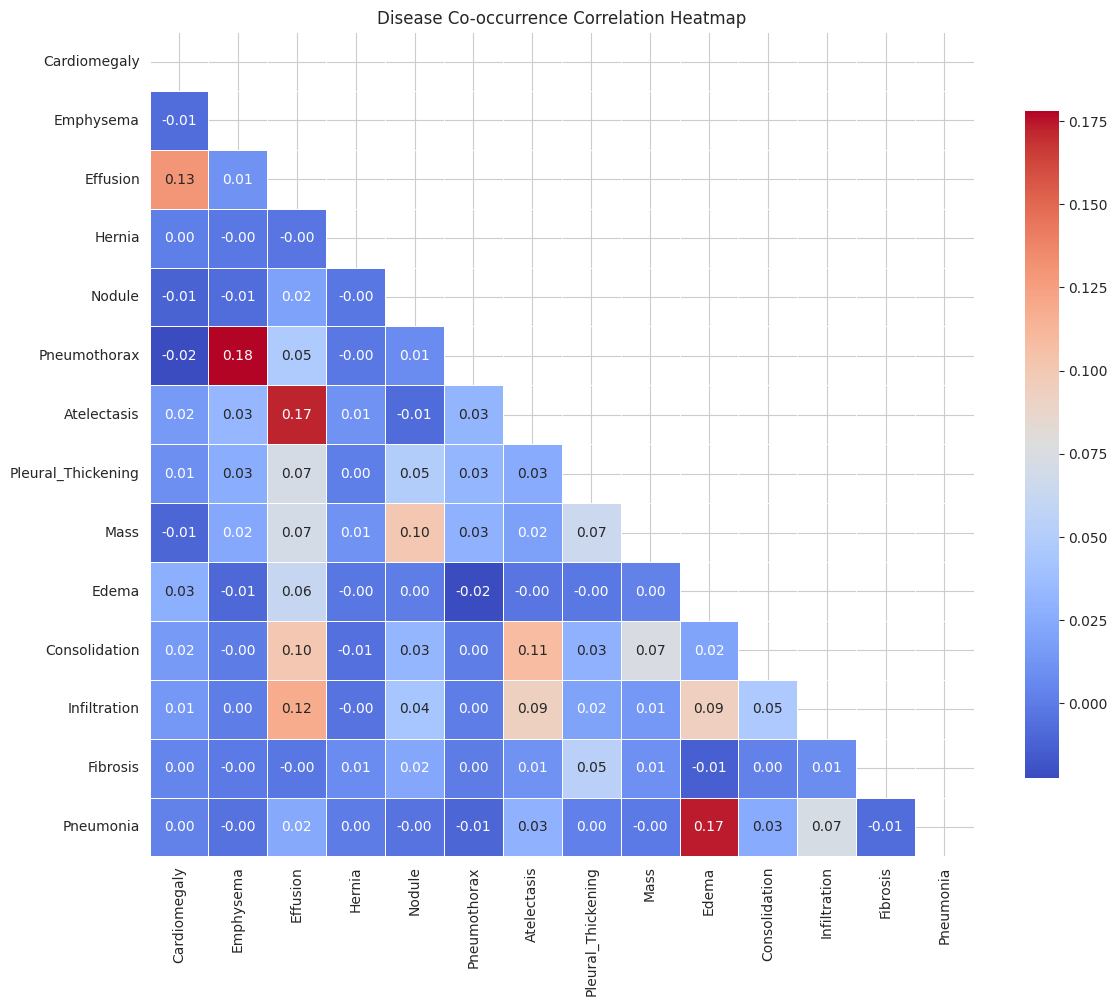

In [14]:
corr = data[pathology_list].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Disease Co-occurrence Correlation Heatmap')
plt.tight_layout()
plt.show()

### Matrix Count
This section presents a co‑occurrence matrix that quantifies how often pairs of chest pathologies appear together in patient records. Each cell shows the count of cases where two diseases co‑exist, with darker shades indicating higher frequencies. The diagonal values represent the total number of cases for each individual disease, while off‑diagonal values highlight common comorbidity patterns such as effusion with infiltration or atelectasis with effusion. This matrix provides a clear overview of disease relationships, supporting multi‑label analysis and helping to identify clinically relevant overlaps.

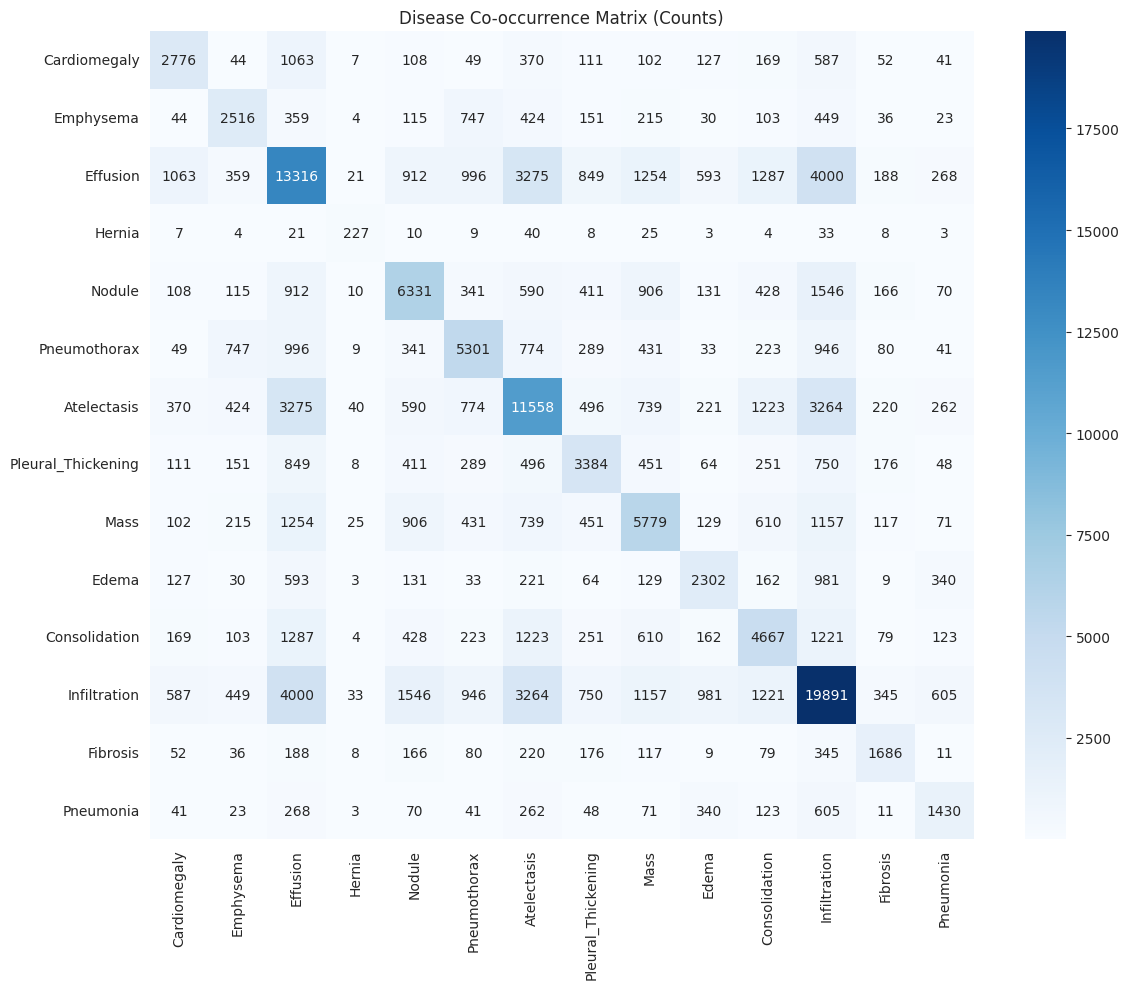

In [15]:
co_occurrence = np.dot(data[pathology_list].T, data[pathology_list])
co_occurrence_df = pd.DataFrame(co_occurrence, 
                                index=pathology_list, 
                                columns=pathology_list)

plt.figure(figsize=(12, 10))
sns.heatmap(co_occurrence_df, annot=True, fmt='d', cmap='Blues')
plt.title("Disease Co-occurrence Matrix (Counts)")
plt.tight_layout()
plt.show()


### Jaccard Similarity
This section presents a heatmap of Jaccard similarity scores between pairs of chest pathologies. The Jaccard index measures how often two diseases occur together relative to their total occurrences, providing a normalized view of co‑occurrence strength. Higher values (closer to 1.0) indicate stronger overlap, while lower values suggest weaker associations. Notable similarities include effusion with atelectasis, effusion with edema, and atelectasis with consolidation. This analysis helps identify clinically relevant disease pairings and supports multi‑label modeling by highlighting conditions that frequently co‑exist.

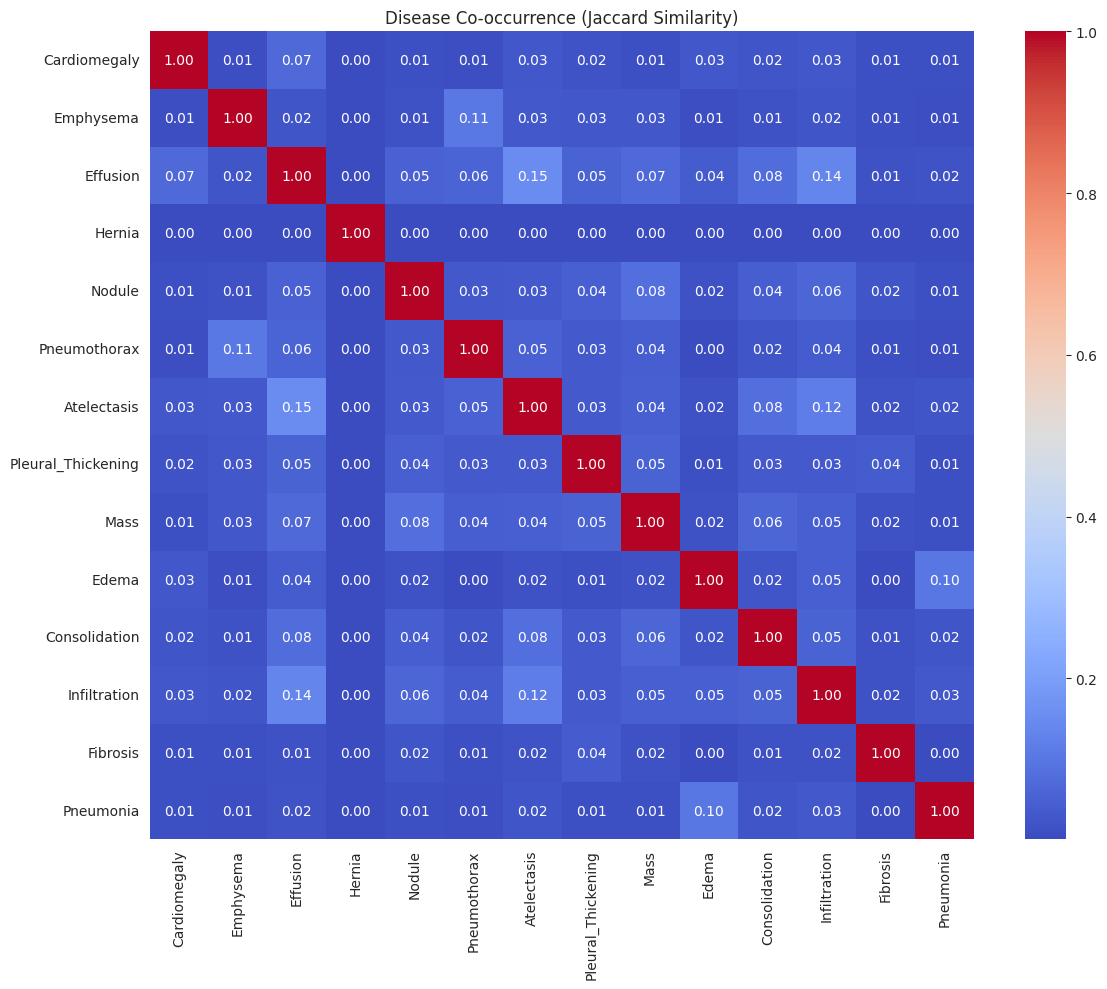

In [16]:
jaccard_matrix = pd.DataFrame(index=pathology_list, columns=pathology_list, dtype=float)

for i in pathology_list:
    for j in pathology_list:
        intersection = np.logical_and(data[i]==1, data[j]==1).sum()
        union = np.logical_or(data[i]==1, data[j]==1).sum()
        jaccard_matrix.loc[i, j] = intersection / union if union != 0 else 0

plt.figure(figsize=(12, 10))
sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Disease Co-occurrence (Jaccard Similarity)")
plt.tight_layout()
plt.show()

## Class Imbalance
This section highlights the imbalance in the dataset across different chest pathologies. Each disease is shown with its case count, prevalence percentage, and imbalance ratio, illustrating how unevenly conditions are represented. Common findings like infiltration and effusion have relatively balanced distributions, while rare conditions such as hernia, fibrosis, and pneumonia show extreme imbalance. Recognizing these disparities is critical for model training, as highly imbalanced classes may require resampling, weighting, or augmentation strategies to ensure fair and accurate predictions.

           Disease  Count  Prevalence (%)  Imbalance Ratio
      Infiltration  19891           17.74             4.64
          Effusion  13316           11.88             7.42
       Atelectasis  11558           10.31             8.70
            Nodule   6331            5.65            16.71
              Mass   5779            5.16            18.40
      Pneumothorax   5301            4.73            20.15
     Consolidation   4667            4.16            23.02
Pleural_Thickening   3384            3.02            32.13
      Cardiomegaly   2776            2.48            39.38
         Emphysema   2516            2.24            43.56
             Edema   2302            2.05            47.70
          Fibrosis   1686            1.50            65.49
         Pneumonia   1430            1.28            77.39
            Hernia    227            0.20           492.85


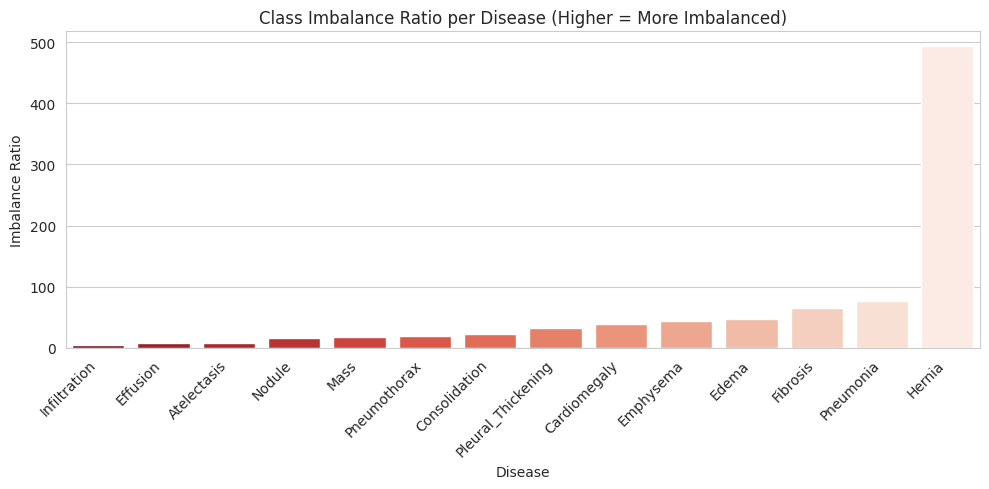

In [17]:
pathology_list = ['Cardiomegaly','Emphysema','Effusion','Hernia',
                  'Nodule','Pneumothorax','Atelectasis','Pleural_Thickening',
                  'Mass','Edema','Consolidation','Infiltration','Fibrosis','Pneumonia']

imbalance_df = pd.DataFrame({
    'Disease': pathology_list,
    'Count': [data[p].sum() for p in pathology_list],
    'Prevalence (%)': [data[p].mean() * 100 for p in pathology_list]
}).sort_values('Count', ascending=False).reset_index(drop=True)

imbalance_df['Imbalance Ratio'] = (len(data) - imbalance_df['Count']) / imbalance_df['Count']
imbalance_df = imbalance_df.round(2)

print(imbalance_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=imbalance_df, x='Disease', y='Imbalance Ratio', palette='Reds_r')
plt.title('Class Imbalance Ratio per Disease (Higher = More Imbalanced)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()